In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql.functions import col, when
from pyspark.sql.types import StringType, NumericType
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

In [0]:
df = spark.read.table("iris.bronze_iris.iris")

In [0]:
# # Identify string columns
# string_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]

# # Fill NaN in string columns with mode (safe check)
# for c in string_cols:
#     mode_row = df.groupBy(c).count().orderBy(col("count").desc()).first()
#     if mode_row is not None and mode_row[c] is not None:
#         mode_val = mode_row[c]
#         df = df.fillna({c: mode_val})

# # Identify numeric columns
# fact_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]

# # Fill NaN in numeric columns with median (safe check)
# for c in fact_cols:
#     median_list = df.approxQuantile(c, [0.5], 0.01)
#     if median_list and median_list[0] is not None:
#         median_val = median_list[0]
#         df = df.withColumn(c, when(col(c).isNull(), median_val).otherwise(col(c)))

# # Step 3: Convert to Pandas for ML
df = df.toPandas()

In [0]:
# Features + Target
X = df[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]]
y = df["Species"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42, max_depth=3)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)


In [0]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


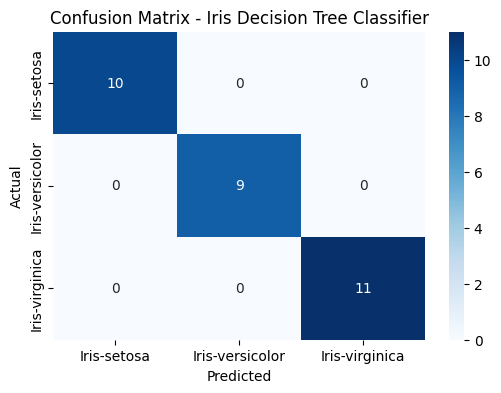

In [0]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt="d",
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Iris Decision Tree Classifier")
plt.show()


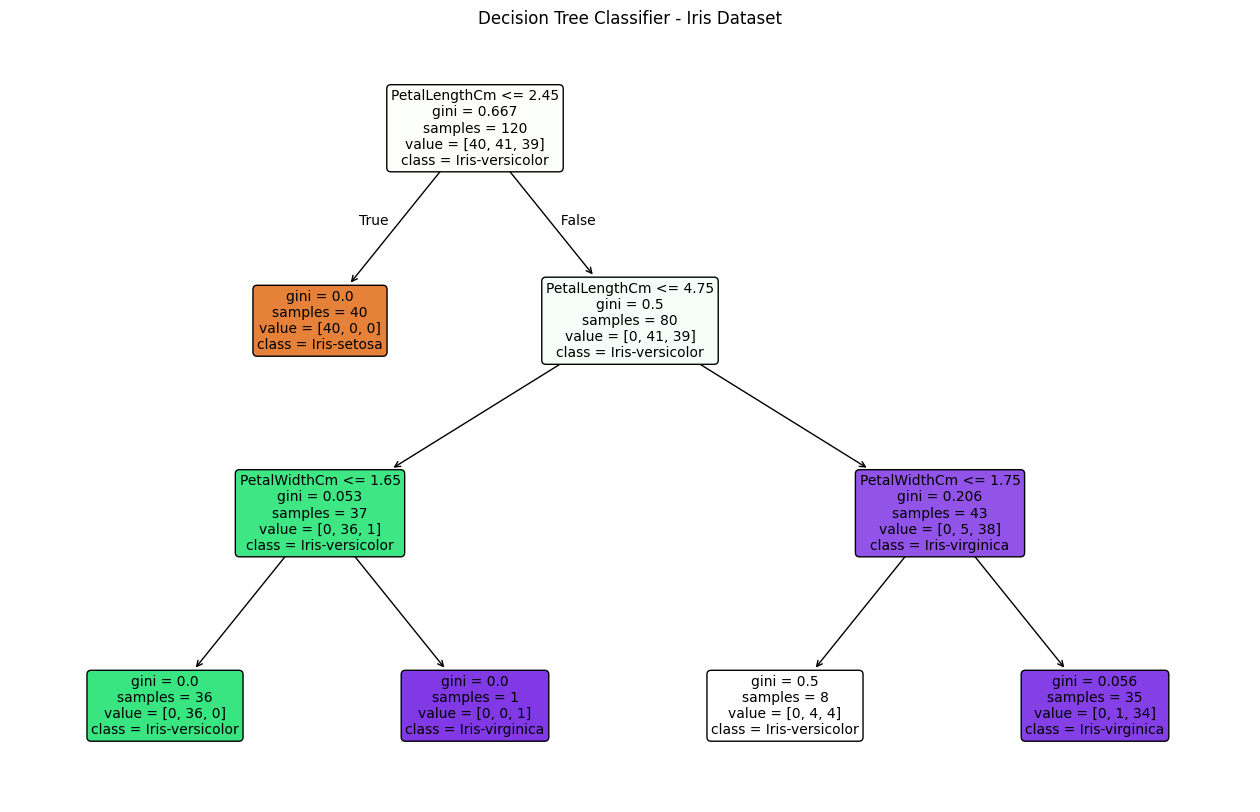

In [0]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16,10))
plot_tree(
    clf,                          # trained classifier model
    feature_names=X.columns,      # feature names (Sepal/Petal measurements)
    class_names=clf.classes_,     # species names (Setosa, Versicolor, Virginica)
    filled=True,                  # color intensity by class
    rounded=True,                 # rounded edges for readability
    fontsize=10
)
plt.title("Decision Tree Classifier - Iris Dataset")
plt.show()


In [0]:
# ==========================================================
# KNN Classification - Iris Dataset
# Save Predictions to iris.silver.iris_predictions
# ==========================================================

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ==========================================================
# Read Delta Table
# ==========================================================

spark_df = spark.read.table("iris.bronze_iris.iris")

# Convert Spark DataFrame to Pandas
pdf = pd.DataFrame(
    spark_df.collect(),
    columns=spark_df.columns
)

# ==========================================================
# Features and Target
# ==========================================================

X = pdf[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

y = pdf["Species"]

# ==========================================================
# Train/Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================================
# Train KNN Model
# ==========================================================

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn.fit(X_train_scaled, y_train)

# ==========================================================
# Test Prediction
# ==========================================================

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")

# ==========================================================
# Classification Report
# ==========================================================

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# ==========================================================
# Predict Entire Dataset
# ==========================================================

X_all_scaled = scaler.transform(X)

pdf["Predicted_Species"] = knn.predict(X_all_scaled)

pdf["Prediction_Status"] = (
    pdf["Species"] == pdf["Predicted_Species"]
)

# ==========================================================
# Convert Back To Spark DataFrame
# ==========================================================

iris_predictions = spark.createDataFrame(pdf)

# ==========================================================
# Display Results
# ==========================================================

display(iris_predictions)

# ==========================================================
# Save To Silver Layer
# ==========================================================

(
    iris_predictions
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable("iris.silver.iris_predictions")
)

print("\nSaved Successfully:")
print("iris.silver.iris_predictions")

Accuracy : 0.9333

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Predicted_Species,Prediction_Status
1,5.1,3.5,1.4,0.2,Iris-setosa,Iris-setosa,true
2,4.9,3.0,1.4,0.2,Iris-setosa,Iris-setosa,true
3,4.7,3.2,1.3,0.2,Iris-setosa,Iris-setosa,true
4,4.6,3.1,1.5,0.2,Iris-setosa,Iris-setosa,true
5,5.0,3.6,1.4,0.2,Iris-setosa,Iris-setosa,true
6,5.4,3.9,1.7,0.4,Iris-setosa,Iris-setosa,true
7,4.6,3.4,1.4,0.3,Iris-setosa,Iris-setosa,true
8,5.0,3.4,1.5,0.2,Iris-setosa,Iris-setosa,true
9,4.4,2.9,1.4,0.2,Iris-setosa,Iris-setosa,true
10,4.9,3.1,1.5,0.1,Iris-setosa,Iris-setosa,true



Saved Successfully:
iris.silver.iris_predictions


In [0]:
# 7. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9333333333333333
Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


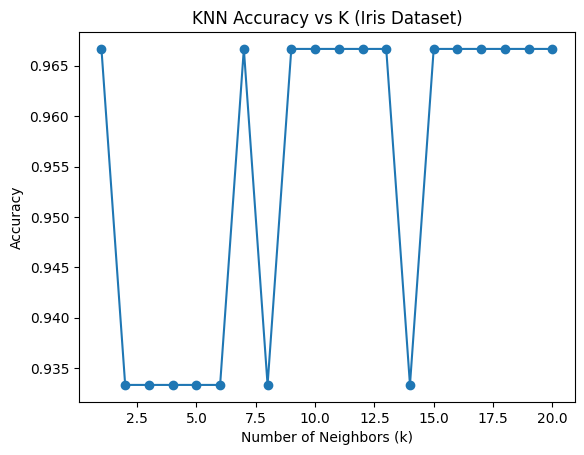

In [0]:
# 8. Accuracy vs K plot
scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    scores.append(knn.score(X_test_scaled, y_test))

plt.plot(range(1,21), scores, marker="o")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K (Iris Dataset)")
plt.show()

In [0]:
# Predict with both models on the full dataset and save to silver table

# Decision Tree predictions on the full dataset
dt_preds = clf.predict(X)

# KNN predictions on the full dataset (scale features first)
X_scaled = scaler.transform(X)
knn_preds = knn.predict(X_scaled)

# Add prediction columns to the original DataFrame
df_predictions = df.copy()
df_predictions["decision_tree_prediction"] = dt_preds
df_predictions["knn_prediction"] = knn_preds

# Convert to Spark DataFrame and save to the silver table
spark_df = spark.createDataFrame(df_predictions)
spark_df.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable("iris.silver.iris_predictions")

print("Predictions saved to iris.iris.silver.iris_predictions")
print("Total rows:", df_predictions.shape[0])
print(df_predictions[["Species", "decision_tree_prediction", "knn_prediction"]].head(10))

Predictions saved to iris.iris.silver.iris_predictions
Total rows: 150
       Species decision_tree_prediction knn_prediction
0  Iris-setosa              Iris-setosa    Iris-setosa
1  Iris-setosa              Iris-setosa    Iris-setosa
2  Iris-setosa              Iris-setosa    Iris-setosa
3  Iris-setosa              Iris-setosa    Iris-setosa
4  Iris-setosa              Iris-setosa    Iris-setosa
5  Iris-setosa              Iris-setosa    Iris-setosa
6  Iris-setosa              Iris-setosa    Iris-setosa
7  Iris-setosa              Iris-setosa    Iris-setosa
8  Iris-setosa              Iris-setosa    Iris-setosa
9  Iris-setosa              Iris-setosa    Iris-setosa
